# **SaaS churn data cleaning and merging**

This notebook focuses on preparing the raw SaaS data for the churn analysis project.

It explores and cleans the main source tables:

- `accounts` – customer profile, company size, country, acquisition channel, account creation date,
- `subscriptions` – plan type, MRR, subscription history and status,
- `support_tickets` – ticket category, status, satisfaction score, ticket date,
- `usage` – product feature usage events and active users,
- `churn_labels` – churn outcome at the account level.

The objective is to:

- understand the structure and quality of each source table,
- fix the most important data quality issues,
- create a few basic derived features when they help the analysis,
- and merge the tables into a clean, account‑level dataset that can be used later for churn exploration and modeling.

# **SaaS churn – data cleaning and merging**

This notebook focuses on preparing the raw SaaS data for the churn analysis project.

It explores and cleans the source tables:
- `accounts` (customer profile and acquisition),
- `subscriptions` (plans and MRR),
- `support_tickets` (categories, status, satisfaction),
- `usage` (feature-level product usage),
- `churn_labels` (account-level churn outcome).

The goal is to highlight data quality issues, understand the structure of each table, and build a clean account-level dataset that can be used in the modeling notebook.


# **Importation des CSV**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
root = "data/"
extension = ".csv"

In [ ]:
saas_accounts = pd.read_csv(f"{root}saas_accounts{extension}")
saas_churn_labels = pd.read_csv(f"{root}saas_churn_labels{extension}")
saas_feature_usage = pd.read_csv(f"{root}saas_feature_usage{extension}")
saas_subscriptions = pd.read_csv(f"{root}saas_subscriptions{extension}")
saas_support_tickets = pd.read_csv(f"{root}saas_support_tickets{extension}")

# **Data cleansing**

## **Accounts dataset**

The `accounts` table contains one row per customer account, including:

- company name and industry,
- company size,
- country,
- acquisition channel,
- account creation date.

In this section, the goals are to:

- confirm the basic data structure,
- convert dates to a proper datetime type,
- and create a few simple features that will be useful later.

In [ ]:
saas_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   account_id           480 non-null    int64 
 1   company_name         480 non-null    object
 2   industry             480 non-null    object
 3   company_size         480 non-null    object
 4   country              480 non-null    object
 5   acquisition_channel  480 non-null    object
 6   account_created_at   480 non-null    object
dtypes: int64(1), object(6)
memory usage: 26.4+ KB


Let's see what is going on for certain fields like "industry", "company_size" and account_created_at"

In [ ]:
saas_accounts["industry"].isnull().sum()

np.int64(0)

In [ ]:
saas_accounts[saas_accounts["industry"].isnull()]

,account_id,company_name,industry,company_size,country,acquisition_channel,account_created_at


20 null values, so I don't know what to think about it, do I need to exclude it or just inform the manager. That is a great question.

"company_size" field  has the right type as it is not clearly an integer but a text.

In [ ]:
saas_accounts["account_created_at_clean"] = pd.to_datetime(saas_accounts["account_created_at"])

In [ ]:
# Let's remove the original field account_created_at
saas_accounts.drop(columns=["account_created_at"], inplace=True, errors='ignore')

# Let's rename the new datetime column to the original name
saas_accounts.rename(columns={"account_created_at_clean": "account_created_at"}, inplace=True)

### **account_id**

In [ ]:
saas_accounts["account_id"].nunique()

480

### **country**

In [ ]:
saas_accounts["country"].value_counts()

,count
country,
UK,99
IT,87
ES,76
FR,75
US,68
DE,65
FR,10


In [ ]:
saas_accounts["country"] = saas_accounts["country"].str.upper()

### **Industry**

In [ ]:
saas_accounts["industry"].value_counts(dropna=False)

,count
industry,
Retail,104
Finance,101
Software,94
Manufacturing,93
Healthcare,88


In [ ]:
# Let's drop the null values as I don't want to guess which industry it might be
saas_accounts.dropna(subset=["industry"], inplace=True)

### **acquisition channel**

In [ ]:
saas_accounts["acquisition_channel"].value_counts()

,count
acquisition_channel,
Partner,123
Inbound,121
Self-serve,119
Outbound,117


### **Company name**

In [ ]:
saas_accounts["company_name"].nunique()

480

### **Duplicated values**

In [ ]:
saas_accounts.duplicated().sum()

np.int64(0)

No duplicated values

In [ ]:
# Once data are cleaned, then turn the dataframe into a csv one
saas_accounts.to_csv("saas_accounts.csv", index=False)

## **Churn labels**

The `churn_labels` table contains the churn outcome at account level:

- one row per account,
- `churned` is a boolean (True / False).

In this notebook, the main steps are to:

- inspect the structure and data types,
- check for missing values,
- keep only the information needed for the analytical dataset.

There are only two fields in this table (`account_id` and `churned`), so no additional features are created here. The cleaned churn labels are merged with the accounts data later.

In [ ]:
saas_churn_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   account_id  411 non-null    int64
 1   churned     411 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 3.7 KB


"churned" field seems to have some nulls, let's see how it goes

In [ ]:
saas_churn_labels[saas_churn_labels["churned"].isnull()]

,account_id,churned


In [ ]:
churned_nulls = saas_churn_labels["churned"].isnull().sum()
rows_churned = len(saas_churn_labels["churned"])

In [ ]:
ratio_nulls_churned = churned_nulls / rows_churned
print(f"{churned_nulls}/{rows_churned}: {ratio_nulls_churned*100:.2}%")

0/411: 0.0%


4,9% of all the churned rows are null

In [ ]:
# Rows with missing churn labels are removed so that the later analysis and modeling use complete target data.
saas_churn_labels["churned"].dropna(inplace=True)

### **Churned**

In [ ]:
saas_churn_labels["churned"] = saas_churn_labels["churned"].astype(bool)

### **Account id**

In [ ]:
saas_churn_labels["account_id"].nunique()

411

### **Duplicated values**

In [ ]:
saas_accounts.duplicated().sum()

np.int64(0)

In [ ]:
# Once data are cleaned, then turn the dataframe into a csv one
saas_churn_labels.to_csv("saas_churn_labels.csv", index=False)

## **Feature usage data**

The `usage` table tracks how accounts use the product features:

- `feature_name`,
- `events_count`,
- `active_users`,
- `event_date`.

In this section, the goals are to:

- verify the structure and basic statistics,
- convert `event_date` to datetime,
- ensure `events_count` values are valid (non‑negative),
- and get a quick view of usage volume per feature.

In [ ]:
saas_feature_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   usage_id      4990 non-null   int64 
 1   account_id    4990 non-null   int64 
 2   feature_name  4990 non-null   object
 3   events_count  4990 non-null   int64 
 4   active_users  4990 non-null   int64 
 5   event_date    4990 non-null   object
dtypes: int64(4), object(2)
memory usage: 234.0+ KB


In [ ]:
saas_feature_usage.head()

,usage_id,account_id,feature_name,events_count,active_users,event_date
0,1,13,code_assist,7,12,2023-05-07
1,2,51,code_assist,6,37,2023-03-25
2,3,495,data_insights,5,33,2023-01-29
3,4,64,dashboard_export,6,40,2023-02-28
4,5,425,code_assist,5,27,2023-06-10


### **Feature name**

In [ ]:
saas_feature_usage["feature_name"].value_counts()

,count
feature_name,
data_insights,1269
chat_completion,1247
code_assist,1244
dashboard_export,1230


### **Event date**

In [ ]:
# Convert `event_date` from object to datetime so that feature usage over time can be analyzed more easily
saas_feature_usage["event_date_cleaned"] = pd.to_datetime(saas_feature_usage["event_date"])

In [ ]:
# Let's remove the original field account_created_at
saas_feature_usage.drop(columns=["event_date"], inplace=True, errors='ignore')

# Let's rename the new datetime column to the original name
saas_feature_usage.rename(columns={"event_date_cleaned": "event_date"}, inplace=True)

### **Event count**

In [ ]:
# Check whether any `events_count` values are negative.
(saas_feature_usage["events_count"] < 0).sum()

np.int64(0)

In [ ]:
# let's create a mask to idenfity the rows with a negative count
mask_events = saas_feature_usage["events_count"] < 0

In [ ]:
# We drop the mask to the current
saas_feature_usage = saas_feature_usage[~mask_events]

### **Duplicated values**

In [ ]:
saas_feature_usage.duplicated().sum()

np.int64(0)

No duplicated values

In [ ]:
# Once data are cleaned, then turn the dataframe into a csv one
saas_feature_usage.to_csv("saas_feature_usage.csv", index=False)

## **Subscription data**

The `subscriptions` table captures the subscription history:

- plan type (Free, Pro, Enterprise),
- monthly recurring revenue in USD (`mrr_usd`),
- whether the subscription is active,
- subscription start and end dates.

In this section, I:

- inspect the table structure,
- convert date fields to datetime,
- check basic distributions (for example, plan types),
- and create simple indicators such as subscription length in days.

In [ ]:
saas_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   subscription_id         15 non-null     int64  
 1   account_id              15 non-null     int64  
 2   plan_type               15 non-null     object 
 3   mrr_usd                 15 non-null     float64
 4   subscription_start      15 non-null     object 
 5   subscription_end        15 non-null     object 
 6   is_active_subscription  15 non-null     bool   
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 867.0+ bytes


### **Subscription start**

In [ ]:
saas_subscriptions.head(15)

,subscription_id,account_id,plan_type,mrr_usd,is_active_subscription,subscription_start,subscription_end
0,3,209,Free,159.69,False,2022-07-19,2022-08-15
1,22,439,Pro,116.17,False,2022-01-05,2022-01-11
2,137,22,Free,216.50,False,2022-11-25,2022-12-12
3,222,454,Free,114.45,False,2021-12-09,2022-01-01
4,225,9,Pro,202.84,False,2022-11-17,2022-11-27
5,258,374,Free,0.00,False,2023-04-29,2023-05-24
6,306,304,Free,85.74,False,2022-10-07,2022-11-05
7,312,301,Pro,0.00,False,2023-04-20,2023-04-23
8,378,111,Free,53.00,False,2023-10-02,2023-10-04
9,553,8,Enterprise,167.37,False,2023-07-30,2023-08-06


### **Plan type**

In [ ]:
saas_subscriptions["plan_type"].value_counts()

,count
plan_type,
Free,6
Pro,6
Enterprise,3


### **Subscription start and end**

In [ ]:
saas_subscriptions["subscription_start"] = pd.to_datetime(saas_subscriptions["subscription_start"])

In [ ]:
saas_subscriptions["subscription_end"] = pd.to_datetime(saas_subscriptions["subscription_end"])

In [ ]:
# We need to switch the two fields because it is reversed
saas_subscriptions["subscription_start_new"] = saas_subscriptions["subscription_end"]
saas_subscriptions["subscription_end_new"] = saas_subscriptions["subscription_start"]

# We remove the old ones
saas_subscriptions.drop(columns=["subscription_end", "subscription_start"], inplace=True)

# We rename the new columns
saas_subscriptions.rename(columns={"subscription_start_new": "subscription_start", "subscription_end_new": "subscription_end"}, inplace=True)

In [ ]:
# check if some end dates are before start dates
mask_end_before_start_dates = saas_subscriptions["subscription_end"] < saas_subscriptions["subscription_start"]
saas_subscriptions = saas_subscriptions[~mask_end_before_start_dates]

In [ ]:
saas_subscriptions["subscription_end"].isnull().sum()

np.int64(0)

In [ ]:
saas_subscriptions[saas_subscriptions["subscription_end"].isnull()]

,subscription_id,account_id,plan_type,mrr_usd,is_active_subscription,subscription_start,subscription_end


Let's create a new column "is_active_subscription" to explicitly mark subscriptions that are still ongoing (subscription_end is null). Then we fill the NaT value in subscription_end with a very distant future date.

In [ ]:
saas_subscriptions["is_active_subscription"] = saas_subscriptions["subscription_end"].isna().astype(bool)

# Fill NaT values in subscription with a distant future date
saas_subscriptions["subscription_end"] = saas_subscriptions["subscription_end"].fillna(pd.Timestamp.max)

Some `subscription_end` values are missing.

In this dataset, missing `subscription_end` indicates subscriptions that are still active, so the field is kept and interpreted accordingly.

### **mrr_usd**

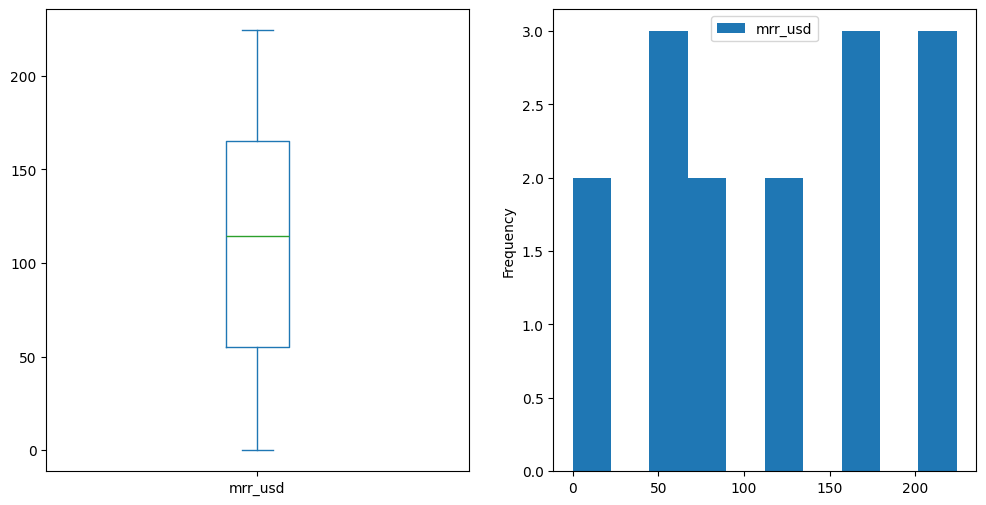

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
saas_subscriptions.plot(kind="box", y="mrr_usd", ax=ax[0])
saas_subscriptions.plot(kind="hist", y="mrr_usd", ax=ax[1])
plt.show()

In [ ]:
# Trouver les outliers
outliers = saas_subscriptions[saas_subscriptions["mrr_usd"] > 450]["mrr_usd"].count()
ratio_outliers = outliers/len(saas_subscriptions["mrr_usd"])
print(f"""Nombre d'outliers - {outliers} et nombre total de lignes - {len(saas_subscriptions["mrr_usd"])},
ce qui donne un ratio de {ratio_outliers*100: .2}%""")

Nombre d'outliers - 0 et nombre total de lignes - 15,
ce qui donne un ratio de  0.0%


In [ ]:
# Let's see if there are negative values just to be sure
mask_mrrusd_negative = saas_subscriptions["mrr_usd"] < 0

In [ ]:
mask_mrrusd_negative.sum()

np.int64(0)

### **Duplicated values**

In [ ]:
saas_subscriptions.duplicated().sum()

np.int64(0)

10 values are duplicated

In [ ]:
# let's drop the duplicated values
saas_subscriptions.drop_duplicates(inplace=True)

In [ ]:
# Once data are cleaned, then turn the dataframe into a csv one
saas_subscriptions.to_csv("saas_subscriptions.csv", index=False)

## **Support tickets data**

The `support_tickets` table contains:

- ticket category (Billing, Bug, Feature request, Onboarding),
- ticket status (Open, Pending, Closed),
- satisfaction score (`csat_score`),
- ticket creation date and month.

Here the goals are to:

- check the distribution of categories and statuses,
- confirm how many tickets have high or low satisfaction scores,
- and prepare the data so that support activity can be aggregated at account level later.

In [ ]:
saas_support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ticket_id   1369 non-null   int64  
 1   account_id  1369 non-null   int64  
 2   created_at  1369 non-null   object 
 3   category    1369 non-null   object 
 4   status      1369 non-null   object 
 5   csat_score  1369 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 64.3+ KB


In [ ]:
saas_support_tickets

,ticket_id,account_id,created_at,category,status,csat_score,created_at_month
0,1,360,2023-02-19,Onboarding,Closed,3.0,February
1,2,261,2023-01-16,Billing,Closed,3.0,January
2,3,236,2023-03-30,Feature request,Closed,4.0,March
3,4,249,2023-04-14,Bug,Closed,1.0,April
4,5,20,2023-06-17,Feature request,Closed,3.0,June
...,...,...,...,...,...,...,...
1364,1495,83,2023-04-01,Feature request,Closed,4.0,April
1365,1496,209,2023-03-20,Billing,Closed,1.0,March
1366,1498,50,2023-02-23,Bug,Closed,4.0,February
1367,1499,489,2023-04-14,Bug,Open,4.0,April


### **Created at**

In [ ]:
saas_support_tickets["created_at"] = pd.to_datetime(saas_support_tickets["created_at"])

### **Category**

In [ ]:
saas_support_tickets["category"].value_counts(dropna=False)

,count
category,
Bug,360
Feature request,347
Onboarding,339
Billing,323


### **Status**

In [ ]:
saas_support_tickets["status"].value_counts()

,count
status,
Closed,967
Pending,257
Open,127
Closed,18


In [ ]:
# Let's put the closed in lowercase to gather the two fields
saas_support_tickets["status"] = saas_support_tickets["status"].str.lower().str.capitalize()

### **Csat score**

In [ ]:
saas_support_tickets["csat_score"].value_counts(dropna=False)

,count
csat_score,
3.0,379
4.0,357
5.0,240
2.0,230
1.0,163


In [ ]:
saas_support_tickets.dropna(subset=["csat_score"], inplace=True)

### **Duplicated values**

In [ ]:
saas_support_tickets.duplicated().sum()

np.int64(0)

No duplicated values

In [ ]:
# Once data are cleaned, then turn the dataframe into a csv one
saas_support_tickets.to_csv("saas_support_tickets.csv", index=False)

## **Summary of cleaning and merging**

This notebook prepares a clean, account‑level dataset for the churn case study.

Key steps included:

- cleaning and enriching the `accounts` table (company size, region, tenure),
- checking and filtering churn labels,
- validating and cleaning usage and subscription data,
- summarizing support tickets by category, status, and satisfaction,
- and merging the information into a single, consistent table.

The resulting dataset is then used in the exploration notebook to analyze churn and in the modeling notebook to build prediction models.